# Auto Insurance Claim Frequency — Exploratory Analysis

This notebook performs exploratory data analysis of the freMTPL2 auto insurance frequency dataset using Python. The analysis examines claim frequency across key risk characteristics, including driver age, vehicle age, BonusMalus, geographic area, and population density, followed by two-variable risk segmentation and visualization.

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [117]:
df = pd.read_csv("freMTPL2freq.csv")
df.head()

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region
0,1.0,1,0.10,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
1,3.0,1,0.77,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
2,5.0,1,0.75,6,2,52,50,B12,Diesel,B,54,Picardie
3,10.0,1,0.09,7,0,46,50,B12,Diesel,B,76,Aquitaine
4,11.0,1,0.84,7,0,46,50,B12,Diesel,B,76,Aquitaine


In [118]:
df.shape

(678013, 12)

In [119]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 678013 entries, 0 to 678012
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   IDpol       678013 non-null  float64
 1   ClaimNb     678013 non-null  int64  
 2   Exposure    678013 non-null  float64
 3   VehPower    678013 non-null  int64  
 4   VehAge      678013 non-null  int64  
 5   DrivAge     678013 non-null  int64  
 6   BonusMalus  678013 non-null  int64  
 7   VehBrand    678013 non-null  str    
 8   VehGas      678013 non-null  str    
 9   Area        678013 non-null  str    
 10  Density     678013 non-null  int64  
 11  Region      678013 non-null  str    
dtypes: float64(2), int64(6), str(4)
memory usage: 76.8 MB


In [120]:
total_claims = df["ClaimNb"].sum()
total_exposure = df["Exposure"].sum()
claim_frequency = total_claims / total_exposure

print("Total claims =", total_claims)
print("Total exposure =", round(total_exposure, 2))
print("Claim frequency =", round(claim_frequency, 4))

Total claims = 36102
Total exposure = 358499.45
Claim frequency = 0.1007


In [121]:
age_bins = [17, 24, 34, 44, 54, 64, float("inf")]

age_labels = [
    "18 to 24",
    "25 to 34",
    "35 to 44",
    "45 to 54",
    "55 to 64",
    "65+"
]

df["AgeCategory"] = pd.cut(
    df["DrivAge"],
    bins=age_bins,
    labels=age_labels
)
df[["DrivAge", "AgeCategory"]].head(10)

,DrivAge,AgeCategory
0,55,55 to 64
1,55,55 to 64
2,52,45 to 54
3,46,45 to 54
4,46,45 to 54
5,38,35 to 44
6,38,35 to 44
7,33,25 to 34
8,33,25 to 34
9,41,35 to 44


In [122]:
df.groupby("AgeCategory", observed=True)["ClaimNb"].sum()

AgeCategory
18 to 24    2364
25 to 34    6396
35 to 44    8145
45 to 54    9513
55 to 64    5124
65+         4560
Name: ClaimNb, dtype: int64

In [123]:
age_summary = df.groupby("AgeCategory",observed=True)[["ClaimNb", "Exposure"]].sum()
age_summary

,ClaimNb,Exposure
AgeCategory,,
18 to 24,2364,12489.161085
25 to 34,6396,64598.614437
35 to 44,8145,87391.452516
45 to 54,9513,89852.746482
55 to 64,5124,56176.951112
65+,4560,47990.519831


In [124]:
age_summary["ClaimFrequency"] = (age_summary["ClaimNb"] / age_summary["Exposure"])
age_summary

,ClaimNb,Exposure,ClaimFrequency
AgeCategory,,,
18 to 24,2364,12489.161085,0.189284
25 to 34,6396,64598.614437,0.099011
35 to 44,8145,87391.452516,0.093201
45 to 54,9513,89852.746482,0.105873
55 to 64,5124,56176.951112,0.091212
65+,4560,47990.519831,0.095019


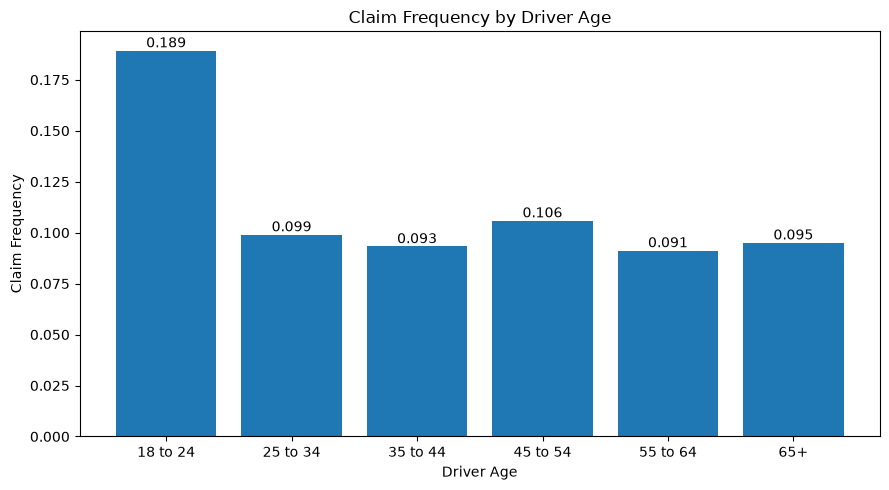

In [125]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    age_summary.index,
    age_summary["ClaimFrequency"]
)

plt.xlabel("Driver Age")
plt.ylabel("Claim Frequency")
plt.title("Claim Frequency by Driver Age")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Driver Age — Key Finding

Drivers aged 18–24 have the highest observed claim frequency at approximately 0.189, substantially above the other age groups. Claim frequencies for the remaining age groups are generally around 0.09–0.11. This suggests driver age may be an important factor for risk segmentation.

In [126]:
bonusmalus_bins=[49,50,75,100,float("inf")]
bonusmalus_labels = [
    "50",
    "51 to 75",
    "76 to 100",
    "101+"
]

df["BonusMalusCategory"] = pd.cut(
    df["BonusMalus"],
    bins=bonusmalus_bins,
    labels=bonusmalus_labels
)
df[["BonusMalus", "BonusMalusCategory"]].head(10)

,BonusMalus,BonusMalusCategory
0,50,50
1,50,50
2,50,50
3,50,50
4,50,50
5,50,50
6,50,50
7,68,51 to 75
8,68,51 to 75
9,50,50


In [127]:
bonusmalus_summary=df.groupby("BonusMalusCategory",observed=True)[["ClaimNb","Exposure"]].sum()
bonusmalus_summary

,ClaimNb,Exposure
BonusMalusCategory,,
50,18056,225233.130902
51 to 75,9614,84874.657297
76 to 100,7090,44820.338259
101+,1342,3571.319003


In [128]:
bonusmalus_summary["ClaimFrequency"]=bonusmalus_summary["ClaimNb"]/bonusmalus_summary["Exposure"]
bonusmalus_summary

,ClaimNb,Exposure,ClaimFrequency
BonusMalusCategory,,,
50,18056,225233.130902,0.080166
51 to 75,9614,84874.657297,0.113273
76 to 100,7090,44820.338259,0.158187
101+,1342,3571.319003,0.375772


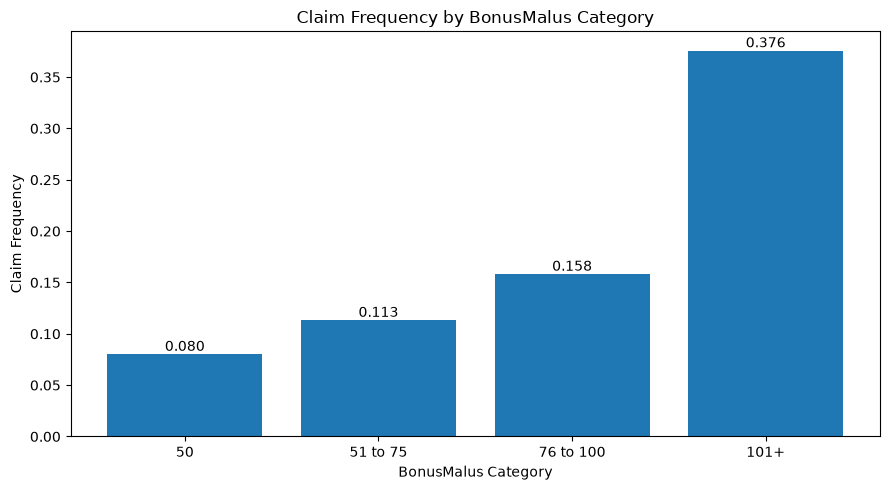

In [129]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    bonusmalus_summary.index,
    bonusmalus_summary["ClaimFrequency"]
)

plt.xlabel("BonusMalus Category")
plt.ylabel("Claim Frequency")
plt.title("Claim Frequency by BonusMalus Category")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### BonusMalus — Key Finding

Observed claim frequency increases substantially as BonusMalus increases. Policies with BonusMalus 101+ have the highest observed claim frequency at approximately 0.376. This strong pattern suggests BonusMalus is an important risk-segmentation variable.

In [130]:
area_summary=df.groupby("Area", observed=True)[["ClaimNb", "Exposure"]].sum()
area_summary

,ClaimNb,Exposure
Area,,
A,5063,61969.377712
B,3800,43012.323931
C,9875,104449.003784
D,8428,77120.191692
E,7805,63819.314270
F,1131,8129.234074


In [131]:
area_summary["ClaimFrequency"]=area_summary["ClaimNb"]/area_summary["Exposure"]
area_summary

,ClaimNb,Exposure,ClaimFrequency
Area,,,
A,5063,61969.377712,0.081702
B,3800,43012.323931,0.088347
C,9875,104449.003784,0.094544
D,8428,77120.191692,0.109284
E,7805,63819.314270,0.122298
F,1131,8129.234074,0.139127


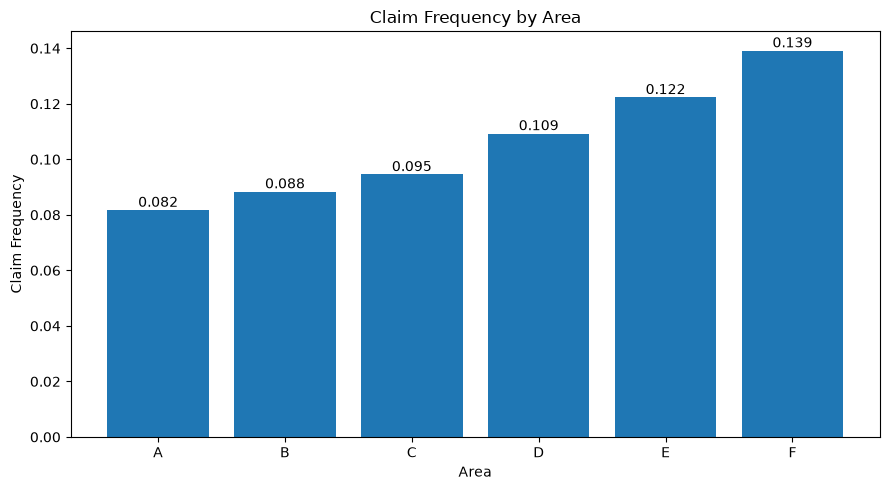

In [132]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    area_summary.index,
    area_summary["ClaimFrequency"]
)

plt.xlabel("Area")
plt.ylabel("Claim Frequency")
plt.title("Claim Frequency by Area")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Area — Key Finding

Observed claim frequency increases consistently from Area A to Area F, with Area A having the lowest frequency and Area F the highest. This indicates meaningful geographic variation in claim frequency. Area is also strongly related to population density, so the effect should not be interpreted independently without further analysis.

In [133]:
df["DensityQuartile"] = pd.qcut(df["Density"],q=4,labels=["Q1", "Q2", "Q3", "Q4"])
df[["Density","DensityQuartile"]].head(10)
df["DensityQuartile"].value_counts().sort_index()

DensityQuartile
Q1    169973
Q2    170244
Q3    168456
Q4    169340
Name: count, dtype: int64

In [134]:
df.groupby("DensityQuartile",observed=True)["Density"].agg(["min", "max", "count"])

,min,max,count
DensityQuartile,,,
Q1,1,92,169973
Q2,93,393,170244
Q3,394,1658,168456
Q4,1662,27000,169340


In [135]:
density_summary=df.groupby("DensityQuartile",observed=True)[["ClaimNb","Exposure"]].sum()
density_summary

,ClaimNb,Exposure
DensityQuartile,,
Q1,8389,99733.989900
Q2,8572,92281.938862
Q3,9311,87962.080039
Q4,9830,78521.436661


In [136]:
density_summary["ClaimFrequency"]=density_summary["ClaimNb"]/density_summary["Exposure"]
density_summary

,ClaimNb,Exposure,ClaimFrequency
DensityQuartile,,,
Q1,8389,99733.989900,0.084114
Q2,8572,92281.938862,0.092889
Q3,9311,87962.080039,0.105852
Q4,9830,78521.436661,0.125189


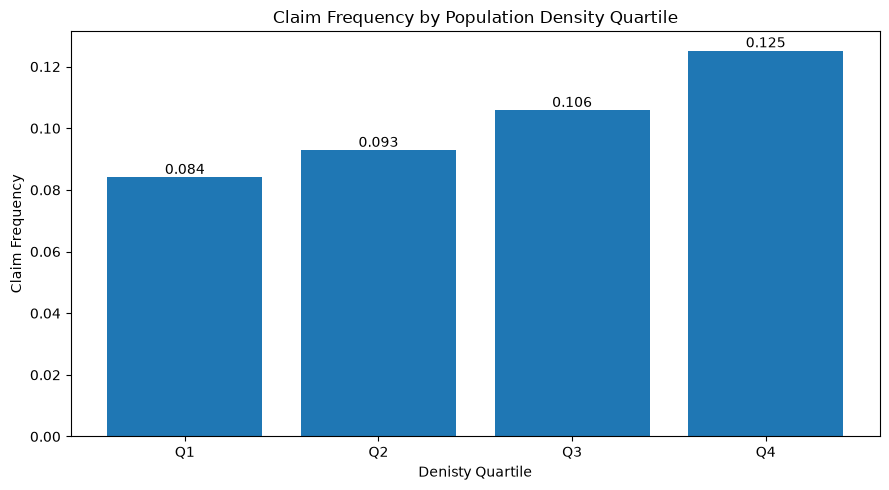

In [137]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    density_summary.index,
    density_summary["ClaimFrequency"]
)

plt.xlabel("Denisty Quartile")
plt.ylabel("Claim Frequency")
plt.title("Claim Frequency by Population Density Quartile")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Population Density — Key Finding

Observed claim frequency increases across population-density quartiles, from approximately 0.084 in Q1 to 0.125 in Q4. This suggests policies in more densely populated areas experience higher observed claim frequency. The result is descriptive and does not establish a causal relationship.

In [138]:
vehage_bins=[-1,10,20,float("inf")]
vehage_labels = [
    "0 to 10",
    "11 to 20",
    "21+"
]

df["VehAgeCategory"] = pd.cut(
    df["VehAge"],
    bins=vehage_bins,
    labels=vehage_labels
)
df[["VehAge", "VehAgeCategory"]].head(10)

,VehAge,VehAgeCategory
0,0,0 to 10
1,0,0 to 10
2,2,0 to 10
3,0,0 to 10
4,0,0 to 10
5,2,0 to 10
6,2,0 to 10
7,0,0 to 10
8,0,0 to 10
9,0,0 to 10


In [139]:
vehage_summary=df.groupby("VehAgeCategory",observed=True)[["ClaimNb","Exposure"]].sum()
vehage_summary

,ClaimNb,Exposure
VehAgeCategory,,
0 to 10,27493,250225.095484
11 to 20,8333,103127.134014
21+,276,5147.215965


In [140]:
vehage_summary["ClaimFrequency"]=vehage_summary["ClaimNb"]/vehage_summary["Exposure"]
vehage_summary

,ClaimNb,Exposure,ClaimFrequency
VehAgeCategory,,,
0 to 10,27493,250225.095484,0.109873
11 to 20,8333,103127.134014,0.080803
21+,276,5147.215965,0.053621


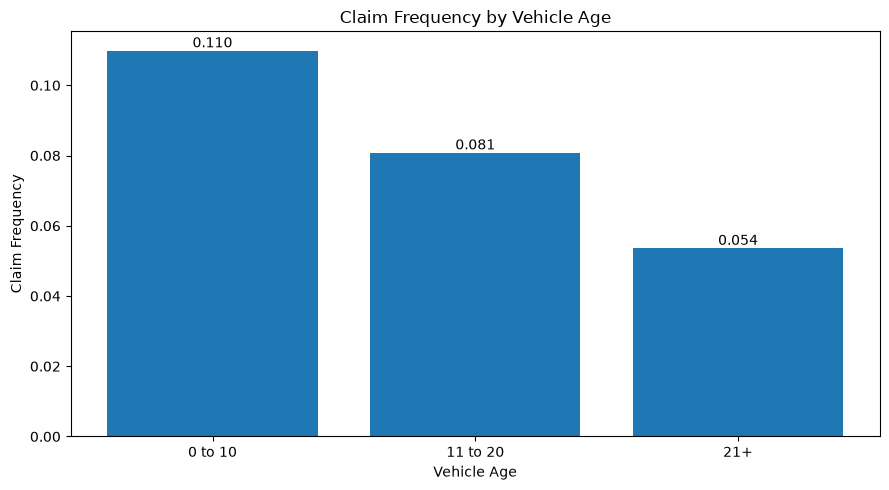

In [141]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    vehage_summary.index,
    vehage_summary["ClaimFrequency"]
)

plt.xlabel("Vehicle Age")
plt.ylabel("Claim Frequency")
plt.title("Claim Frequency by Vehicle Age")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Population Density — Key Finding

Observed claim frequency increases across population-density quartiles, from approximately 0.084 in Q1 to 0.125 in Q4. This suggests policies in more densely populated areas experience higher observed claim frequency. The result is descriptive and does not establish a causal relationship.

In [142]:
age_bonus_summary=df.groupby(["AgeCategory", "BonusMalusCategory"],observed=True)[["ClaimNb","Exposure"]].sum()
age_bonus_summary

ClaimNb      Exposure
AgeCategory BonusMalusCategory                       
18 to 24    50                       63    520.942025
            51 to 75                 74   1035.217711
            76 to 100              1760   9861.295327
            101+                    467   1071.706022
25 to 34    50                      576  10956.629368
            51 to 75               2762  33476.648890
            76 to 100              2667  18911.851830
            101+                    391   1253.484348
35 to 44    50                     3889  53922.040395
            51 to 75               2821  24817.680158
            76 to 100              1231   8101.119969
            101+                    204    550.611995
45 to 54    50                     6539  71551.165036
            51 to 75               2032  13456.167089
            76 to 100               822   4502.664258
            101+                    120    342.750100
55 to 64    50                     3608  46619.181263
            51 to 75               1053   7139.646985
            76 to 100               374   2207.432742
            101+                     89    210.690122
65+         50                     3381  41663.172815
            51 to 75                872   4949.296465
            76 to 100               236   1235.974134
            101+                     71    142.076416

In [143]:
age_bonus_summary["ClaimFrequency"]=age_bonus_summary["ClaimNb"]/age_bonus_summary["Exposure"]
age_bonus_summary

ClaimNb      Exposure  ClaimFrequency
AgeCategory BonusMalusCategory                                       
18 to 24    50                       63    520.942025        0.120935
            51 to 75                 74   1035.217711        0.071483
            76 to 100              1760   9861.295327        0.178476
            101+                    467   1071.706022        0.435754
25 to 34    50                      576  10956.629368        0.052571
            51 to 75               2762  33476.648890        0.082505
            76 to 100              2667  18911.851830        0.141023
            101+                    391   1253.484348        0.311931
35 to 44    50                     3889  53922.040395        0.072123
            51 to 75               2821  24817.680158        0.113669
            76 to 100              1231   8101.119969        0.151954
            101+                    204    550.611995        0.370497
45 to 54    50                     6539  71551.165036        0.091389
            51 to 75               2032  13456.167089        0.151009
            76 to 100               822   4502.664258        0.182559
            101+                    120    342.750100        0.350109
55 to 64    50                     3608  46619.181263        0.077393
            51 to 75               1053   7139.646985        0.147486
            76 to 100               374   2207.432742        0.169428
            101+                     89    210.690122        0.422421
65+         50                     3381  41663.172815        0.081151
            51 to 75                872   4949.296465        0.176187
            76 to 100               236   1235.974134        0.190943
            101+                     71    142.076416        0.499731

In [144]:
age_bonus_pivot = age_bonus_summary["ClaimFrequency"].unstack()
age_bonus_pivot

BonusMalusCategory,50,51 to 75,76 to 100,101+
AgeCategory,,,,
18 to 24,0.120935,0.071483,0.178476,0.435754
25 to 34,0.052571,0.082505,0.141023,0.311931
35 to 44,0.072123,0.113669,0.151954,0.370497
45 to 54,0.091389,0.151009,0.182559,0.350109
55 to 64,0.077393,0.147486,0.169428,0.422421
65+,0.081151,0.176187,0.190943,0.499731


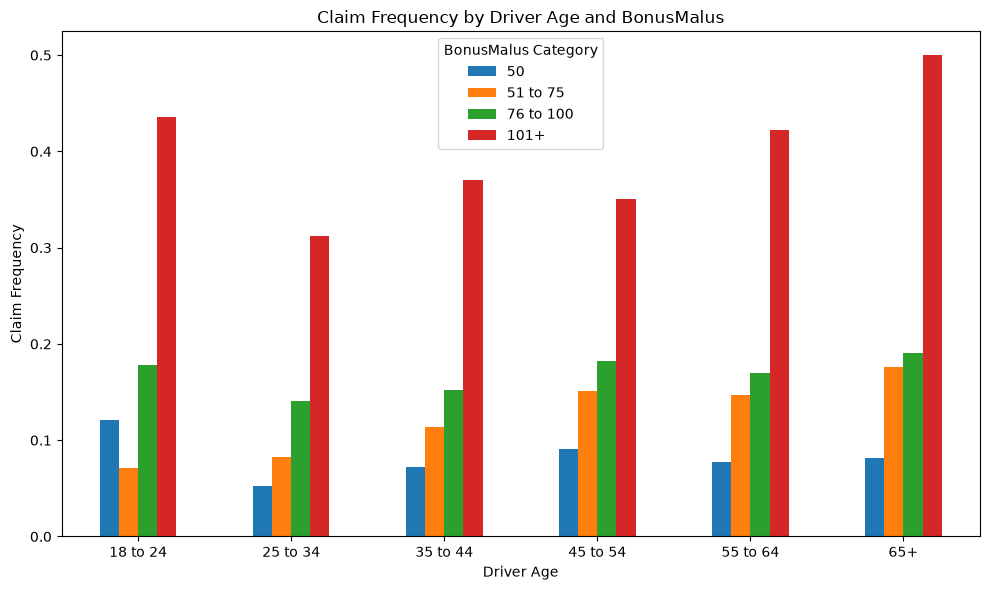

In [145]:
age_bonus_pivot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Driver Age")
plt.ylabel("Claim Frequency")
plt.title("Claim Frequency by Driver Age and BonusMalus")
plt.legend(title="BonusMalus Category")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Key Finding

Observed claim frequency generally increases as BonusMalus increases across driver age groups. The BonusMalus 101+ category exhibits substantially higher claim frequency across all age groups. However, some high-BonusMalus segments have relatively low exposure, so these estimates should be interpreted cautiously.

In [146]:
vehage_agecategory_summary=df.groupby(["AgeCategory", "VehAgeCategory"],observed=True)[["ClaimNb","Exposure"]].sum()
vehage_agecategory_summary

ClaimNb      Exposure
AgeCategory VehAgeCategory                       
18 to 24    0 to 10            1566   7834.192015
            11 to 20            780   4561.219906
            21+                  18     93.749163
25 to 34    0 to 10            5042  46195.046884
            11 to 20           1325  17781.371882
            21+                  29    622.195671
35 to 44    0 to 10            6158  58985.886082
            11 to 20           1928  27253.324218
            21+                  59   1152.242216
45 to 54    0 to 10            7189  62610.368311
            11 to 20           2262  25967.257798
            21+                  62   1275.120374
55 to 64    0 to 10            4011  40449.866548
            11 to 20           1071  14774.818833
            21+                  42    952.265731
65+         0 to 10            3527  34149.735645
            11 to 20            967  12789.141377
            21+                  66   1051.642809

In [147]:
vehage_agecategory_summary["ClaimFrequency"]=vehage_agecategory_summary["ClaimNb"]/vehage_agecategory_summary["Exposure"]
vehage_agecategory_summary

ClaimNb      Exposure  ClaimFrequency
AgeCategory VehAgeCategory                                       
18 to 24    0 to 10            1566   7834.192015        0.199893
            11 to 20            780   4561.219906        0.171007
            21+                  18     93.749163        0.192002
25 to 34    0 to 10            5042  46195.046884        0.109146
            11 to 20           1325  17781.371882        0.074516
            21+                  29    622.195671        0.046609
35 to 44    0 to 10            6158  58985.886082        0.104398
            11 to 20           1928  27253.324218        0.070744
            21+                  59   1152.242216        0.051205
45 to 54    0 to 10            7189  62610.368311        0.114821
            11 to 20           2262  25967.257798        0.087110
            21+                  62   1275.120374        0.048623
55 to 64    0 to 10            4011  40449.866548        0.099160
            11 to 20           1071  14774.818833        0.072488
            21+                  42    952.265731        0.044105
65+         0 to 10            3527  34149.735645        0.103280
            11 to 20            967  12789.141377        0.075611
            21+                  66   1051.642809        0.062759

In [148]:
vehage_agecategory_pivot = vehage_agecategory_summary["ClaimFrequency"].unstack()
vehage_agecategory_pivot

VehAgeCategory,0 to 10,11 to 20,21+
AgeCategory,,,
18 to 24,0.199893,0.171007,0.192002
25 to 34,0.109146,0.074516,0.046609
35 to 44,0.104398,0.070744,0.051205
45 to 54,0.114821,0.087110,0.048623
55 to 64,0.099160,0.072488,0.044105
65+,0.103280,0.075611,0.062759


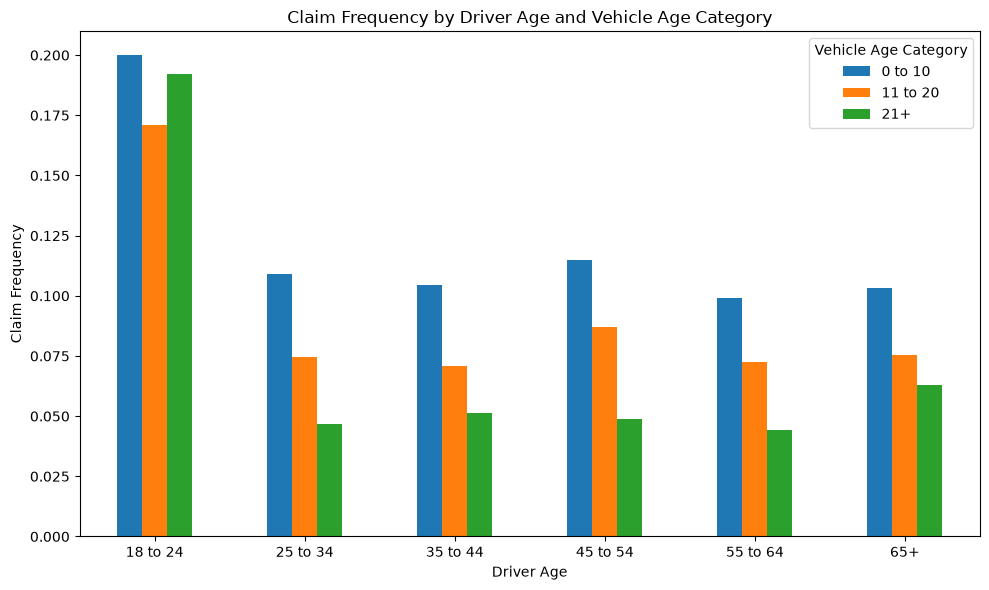

In [149]:
vehage_agecategory_pivot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Driver Age")
plt.ylabel("Claim Frequency")
plt.title("Claim Frequency by Driver Age and Vehicle Age Category")
plt.legend(title="Vehicle Age Category")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Driver Age × Vehicle Age — Key Finding

Drivers aged 18–24 exhibit substantially higher observed claim frequency across all vehicle-age categories compared with other driver age groups. For most age groups, claim frequency decreases as vehicle age increases. The 21+ vehicle segment for drivers aged 18–24 has relatively limited exposure, so its observed frequency should be interpreted cautiously. Overall, driver age and vehicle age appear to provide complementary information for risk segmentation.